## CDC Diabetes Health Indicators

https://archive.ics.uci.edu/dataset/891/cdc+diabetes+health+indicators

In [59]:
data_url =  'https://archive.ics.uci.edu/static/public/891/data.csv'

In [60]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler, OneHotEncoder

from imblearn.over_sampling import SMOTE
from sklearn.utils.class_weight import compute_sample_weight

# from sklearn.datasets import make_classification
# from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, GridSearchCV, RepeatedStratifiedKFold
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score, precision_score, recall_score, f1_score, roc_curve, auc

from sklearn.linear_model import LogisticRegression

import xgboost as xgb

from sklearn.neighbors import KNeighborsClassifier


from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import plot_tree

from sklearn.svm import SVC




In [61]:
data = pd.read_csv(data_url)

In [62]:
df = data.copy()

In [63]:
df.shape

(253680, 23)

In [64]:
pd.set_option('display.max_columns', None)
df.head()

,ID,Diabetes_binary,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,Veggies,HvyAlcoholConsump,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
0,0,0,1,1,1,40,1,0,0,0,0,1,0,1,0,5,18,15,1,0,9,4,3
1,1,0,0,0,0,25,1,0,0,1,0,0,0,0,1,3,0,0,0,0,7,6,1
2,2,0,1,1,1,28,0,0,0,0,1,0,0,1,1,5,30,30,1,0,9,4,8
3,3,0,1,0,1,27,0,0,0,1,1,1,0,1,0,2,0,0,0,0,11,3,6
4,4,0,1,1,1,24,0,0,0,1,1,1,0,1,0,2,3,0,0,0,11,5,4


In [65]:
np.transpose(df.describe())

,count,mean,std,min,25%,50%,75%,max
ID,253680.0,126839.500000,73231.252481,0.0,63419.75,126839.5,190259.25,253679.0
Diabetes_binary,253680.0,0.139333,0.346294,0.0,0.00,0.0,0.00,1.0
HighBP,253680.0,0.429001,0.494934,0.0,0.00,0.0,1.00,1.0
HighChol,253680.0,0.424121,0.494210,0.0,0.00,0.0,1.00,1.0
CholCheck,253680.0,0.962670,0.189571,0.0,1.00,1.0,1.00,1.0
BMI,253680.0,28.382364,6.608694,12.0,24.00,27.0,31.00,98.0
Smoker,253680.0,0.443169,0.496761,0.0,0.00,0.0,1.00,1.0
Stroke,253680.0,0.040571,0.197294,0.0,0.00,0.0,0.00,1.0
HeartDiseaseorAttack,253680.0,0.094186,0.292087,0.0,0.00,0.0,0.00,1.0
PhysActivity,253680.0,0.756544,0.429169,0.0,1.00,1.0,1.00,1.0


In [66]:
df.shape

(253680, 23)

In [67]:
df['ID'].nunique() == df.shape[0] #unique entries

True

In [68]:
duplicates = df[df.duplicated()]

print(f'There are {len(duplicates)} duplicate rows')

There are 0 duplicate rows


In [69]:
df.drop(columns = 'ID', axis = 1, inplace= True)

In [70]:
print(df[df.isnull().any(axis=1)].sum()) #rows with atleast one NaN

Diabetes_binary         0
HighBP                  0
HighChol                0
CholCheck               0
BMI                     0
Smoker                  0
Stroke                  0
HeartDiseaseorAttack    0
PhysActivity            0
Fruits                  0
Veggies                 0
HvyAlcoholConsump       0
AnyHealthcare           0
NoDocbcCost             0
GenHlth                 0
MentHlth                0
PhysHlth                0
DiffWalk                0
Sex                     0
Age                     0
Education               0
Income                  0
dtype: int64


In [71]:
[(i,len(set(df[i]))) for i in df.columns if len(set(df[i]))<3] #binary variables

[('Diabetes_binary', 2),
 ('HighBP', 2),
 ('HighChol', 2),
 ('CholCheck', 2),
 ('Smoker', 2),
 ('Stroke', 2),
 ('HeartDiseaseorAttack', 2),
 ('PhysActivity', 2),
 ('Fruits', 2),
 ('Veggies', 2),
 ('HvyAlcoholConsump', 2),
 ('AnyHealthcare', 2),
 ('NoDocbcCost', 2),
 ('DiffWalk', 2),
 ('Sex', 2)]

In [72]:
[(i,len(set(df[i]))) for i in df.columns if len(set(df[i]))>2]

[('BMI', 84),
 ('GenHlth', 5),
 ('MentHlth', 31),
 ('PhysHlth', 31),
 ('Age', 13),
 ('Education', 6),
 ('Income', 8)]

In [73]:
diff_scales = [i for i in df.columns if len(set(df[i]))>2]

In [74]:
bins = [12, 18, 25, 30, 35, 40,  float('inf')]
labels = ['Underweight', 'Healthy_Weight', 'Overweight', 'Obesity_Class1', 'Obesity_Class2', 'Obesity_Class3']

df['BMI_cat'] = pd.cut(df['BMI'], bins=bins, labels=labels, right=False).cat.codes


# Underweight: BMI less than 18.5
# Healthy weight: BMI between 18.5 and 24.9
# Overweight: BMI between 25 and 29.9
# Obesity: BMI of 30 or higher, which is further divided into three classes:
# Class 1: BMI 30 to 34.9
# Class 2: BMI 35 to 39.9
# Class 3: BMI 40 or higher

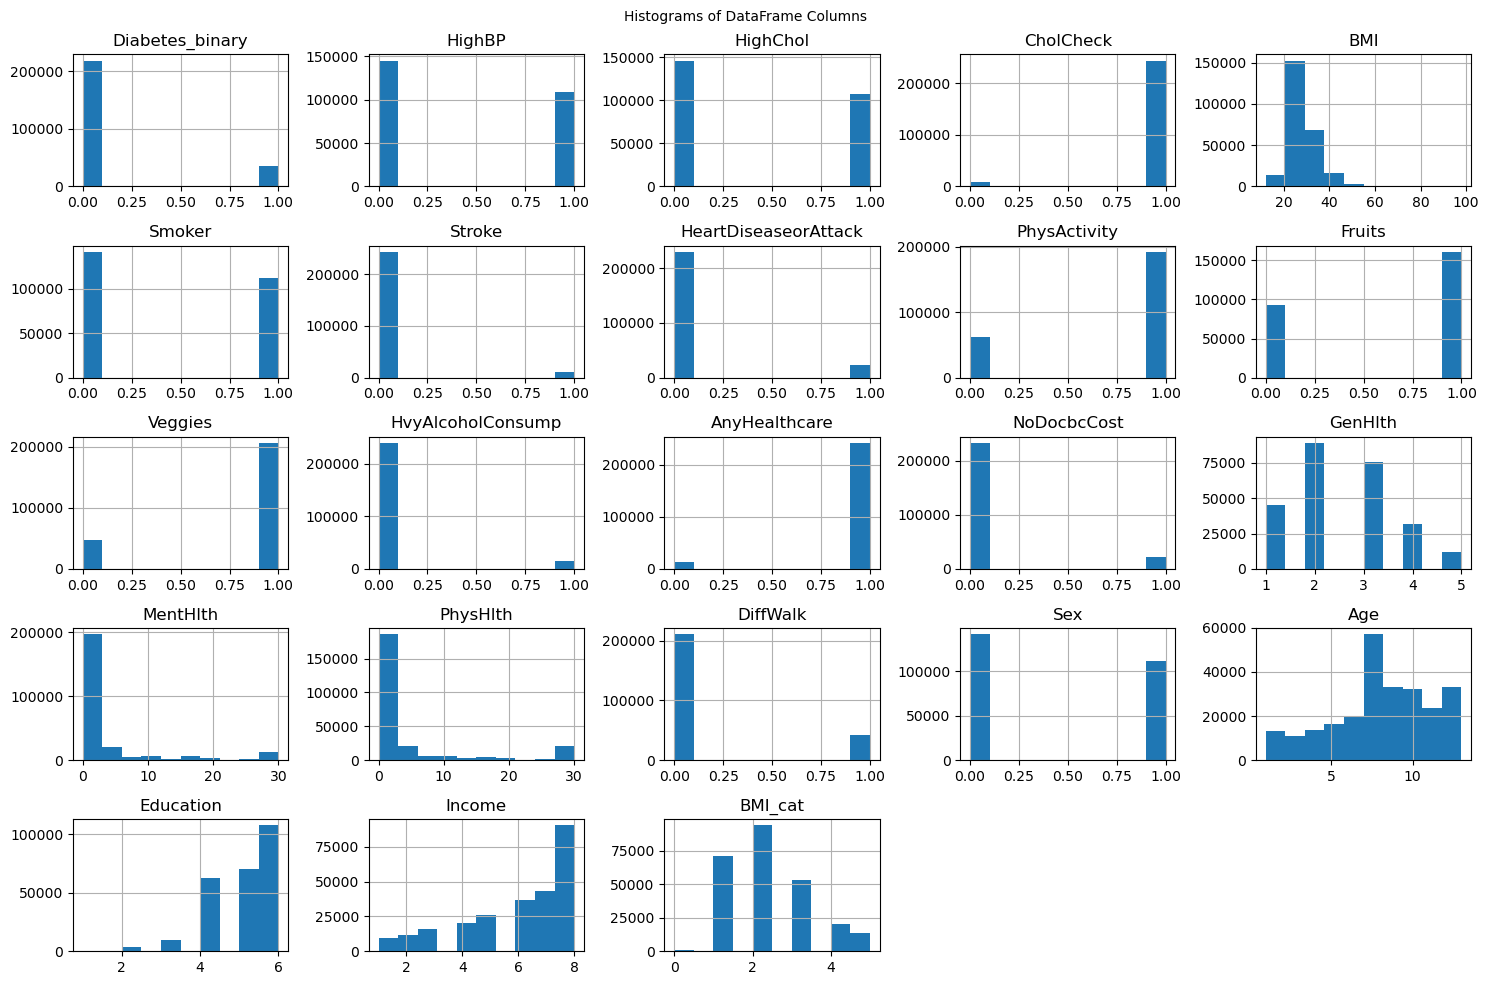

In [75]:
df.hist(figsize=(15,10)) #check distribution
plt.suptitle("Histograms of DataFrame Columns", fontsize = 10)
plt.tight_layout()
plt.show()

In [76]:
df.head()

,Diabetes_binary,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,Veggies,HvyAlcoholConsump,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income,BMI_cat
0,0,1,1,1,40,1,0,0,0,0,1,0,1,0,5,18,15,1,0,9,4,3,5
1,0,0,0,0,25,1,0,0,1,0,0,0,0,1,3,0,0,0,0,7,6,1,2
2,0,1,1,1,28,0,0,0,0,1,0,0,1,1,5,30,30,1,0,9,4,8,2
3,0,1,0,1,27,0,0,0,1,1,1,0,1,0,2,0,0,0,0,11,3,6,2
4,0,1,1,1,24,0,0,0,1,1,1,0,1,0,2,3,0,0,0,11,5,4,1


In [77]:
continuous = ['MentHlth', 'PhysHlth', 'BMI']
columns_to_encode = [col for col in df.columns if col not in continuous]
c_df = pd.get_dummies(data = df, 
                      columns = columns_to_encode, 
                      drop_first = True)
print(c_df)

        BMI  MentHlth  PhysHlth  Diabetes_binary_1  HighBP_1  HighChol_1  \
0        40        18        15              False      True        True   
1        25         0         0              False     False       False   
2        28        30        30              False      True        True   
3        27         0         0              False      True       False   
4        24         3         0              False      True        True   
...     ...       ...       ...                ...       ...         ...   
253675   45         0         5              False      True        True   
253676   18         0         0               True      True        True   
253677   28         0         0              False     False       False   
253678   23         0         0              False      True       False   
253679   25         0         0               True      True        True   

        CholCheck_1  Smoker_1  Stroke_1  HeartDiseaseorAttack_1  \
0              True 

In [78]:
scaler = StandardScaler()
c_df[continuous] = scaler.fit_transform(c_df[continuous])

In [79]:
X = c_df.loc[:, c_df.columns != 'Diabetes_binary_1']

In [80]:
y = c_df.loc[:,'Diabetes_binary_1']

In [81]:
X_train, X_test, y_train, y_test = train_test_split(X, 
                                                    y, 
                                                    random_state = 0, 
                                                    test_size=.3, 
                                                    stratify = y)

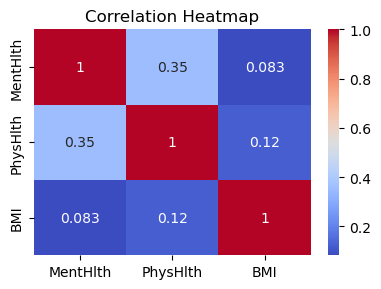

In [82]:
corr_matrix = X_train[continuous].corr()
plt.figure(figsize = (4,3))
sns.heatmap(corr_matrix, 
            annot = True, 
            cmap = 'coolwarm')
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

### Logistic Regression

In [83]:
LRmodel = LogisticRegression(class_weight = 'balanced', #'balanced': This mode adjusts the weights inversely proportional to class frequencies n_samples / (n_classes * np.bincount(y)
                            solver = 'lbfgs',
                            max_iter = 100,
                            random_state = 0) #Ridge L2

In [84]:
LRmodel.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,'balanced'
,random_state,0
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [85]:
print("The Full Model")
coefficients = LRmodel.coef_[0]
features = X_train.columns

for feature, coef in zip(features, coefficients):
    print(f"{feature}: {coef:.4f}")

The Full Model
BMI: 0.1929
MentHlth: -0.0265
PhysHlth: -0.0237
HighBP_1: 0.6770
HighChol_1: 0.5366
CholCheck_1: 1.2578
Smoker_1: -0.0081
Stroke_1: 0.1689
HeartDiseaseorAttack_1: 0.2801
PhysActivity_1: -0.0465
Fruits_1: -0.0233
Veggies_1: -0.0208
HvyAlcoholConsump_1: -0.7399
AnyHealthcare_1: 0.0227
NoDocbcCost_1: 0.0411
GenHlth_2: 0.7228
GenHlth_3: 1.4272
GenHlth_4: 1.9005
GenHlth_5: 2.0680
DiffWalk_1: 0.1121
Sex_1: 0.2799
Age_2: 0.0078
Age_3: 0.3665
Age_4: 0.7380
Age_5: 1.0150
Age_6: 1.1976
Age_7: 1.4405
Age_8: 1.5256
Age_9: 1.7288
Age_10: 1.9460
Age_11: 2.0244
Age_12: 1.9834
Age_13: 1.8646
Education_2: -0.5428
Education_3: -0.6998
Education_4: -0.7708
Education_5: -0.7407
Education_6: -0.8282
Income_2: -0.0147
Income_3: -0.0734
Income_4: -0.1288
Income_5: -0.1835
Income_6: -0.2759
Income_7: -0.2893
Income_8: -0.4365
BMI_cat_1: 0.0735
BMI_cat_2: 0.4359
BMI_cat_3: 0.7818
BMI_cat_4: 1.0054
BMI_cat_5: 1.0160


In [86]:
y_pred = LRmodel.predict(X_test)
y_prob = LRmodel.predict_proba(X_test)[:, 1] #positive

In [87]:
# Metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1 Score: {f1:.4f}")


Accuracy: 0.7291
Precision: 0.3100
Recall: 0.7704
F1 Score: 0.4421


In [88]:
print(classification_report(y_test, y_pred, digits=4))

              precision    recall  f1-score   support

       False     0.9511    0.7224    0.8211     65500
        True     0.3100    0.7704    0.4421     10604

    accuracy                         0.7291     76104
   macro avg     0.6305    0.7464    0.6316     76104
weighted avg     0.8617    0.7291    0.7683     76104



Confusion Matrix:


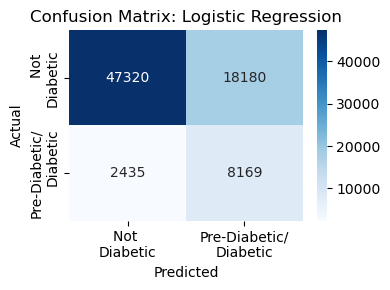

In [89]:
print("Confusion Matrix:")
LRcm = confusion_matrix(y_test, y_pred)
plt.figure(figsize = (4,3))
sns.heatmap(LRcm,
            annot=True, 
            fmt='d', 
            cmap='Blues', 
            xticklabels=['Not \nDiabetic', 'Pre-Diabetic/\nDiabetic'], 
            yticklabels=['Not \nDiabetic', 'Pre-Diabetic/\nDiabetic'])
plt.title("Confusion Matrix: Logistic Regression")
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

In [90]:
roc_auc = roc_auc_score(y_test, y_prob)
print(f"ROC-AUC Score: {roc_auc:.4f}")

ROC-AUC Score: 0.8253


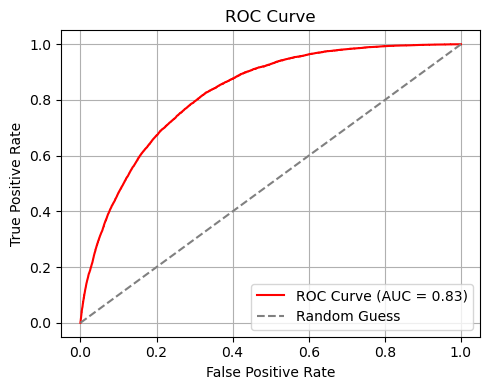

In [91]:
fpr, tpr, _ = roc_curve(y_test, y_prob) #three arrays: fpr, tpr, thresholds
roc_auc = auc(fpr, tpr)

plt.figure(figsize = (5,4))
plt.plot(fpr, tpr, label=f"ROC Curve (AUC = {roc_auc:.2f})", color="red")
plt.plot([0, 1], [0, 1], linestyle='--', color="gray", label = 'Random Guess')  # Random guess line
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.grid(True)
plt.title("ROC Curve")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

In [92]:
feature_names = [f"feature: {col}" for col in X_train.columns]
importance = pd.Series(LRmodel.coef_[0], index=feature_names)
print("\nFeature with respective coefficients for full model:")
print(importance)


Feature with respective coefficients for full model:
feature: BMI                       0.192899
feature: MentHlth                 -0.026460
feature: PhysHlth                 -0.023702
feature: HighBP_1                  0.677012
feature: HighChol_1                0.536564
feature: CholCheck_1               1.257849
feature: Smoker_1                 -0.008074
feature: Stroke_1                  0.168933
feature: HeartDiseaseorAttack_1    0.280069
feature: PhysActivity_1           -0.046460
feature: Fruits_1                 -0.023287
feature: Veggies_1                -0.020804
feature: HvyAlcoholConsump_1      -0.739944
feature: AnyHealthcare_1           0.022733
feature: NoDocbcCost_1             0.041131
feature: GenHlth_2                 0.722756
feature: GenHlth_3                 1.427174
feature: GenHlth_4                 1.900481
feature: GenHlth_5                 2.068010
feature: DiffWalk_1                0.112111
feature: Sex_1                     0.279906
feature: Age_2        

In [93]:
np.round(LRmodel.intercept_, 4)

array([-4.45])

### Random Forest

In [94]:
smote_sampling = SMOTE(random_state = 0) # synthetic minority oversampling technique, creating synthetic samples based on the K nearest neighbors of every point of data
X_train_smote, y_train_smote = smote_sampling.fit_resample(X_train, y_train) # only applied on training

In [95]:
unique, count = np.unique(y_train_smote, return_counts = True)
y_train_smote_valueCount = {c:n for (c,n) in zip(unique, count)}
y_train_smote_valueCount # ratio

{np.False_: np.int64(152834), np.True_: np.int64(152834)}

In [96]:
rfModel = RandomForestClassifier(random_state = 0)

In [97]:
rfModel.fit(X_train_smote, y_train_smote)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [98]:
y_pred = rfModel.predict(X_test)
y_prob = rfModel.predict_proba(X_test)[:, 1]

In [99]:
# Metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1 Score: {f1:.4f}")


Accuracy: 0.8354
Precision: 0.4042
Recall: 0.3828
F1 Score: 0.3932


In [100]:
print(classification_report(y_test, y_pred, digits=4))

              precision    recall  f1-score   support

       False     0.9009    0.9087    0.9048     65500
        True     0.4042    0.3828    0.3932     10604

    accuracy                         0.8354     76104
   macro avg     0.6526    0.6457    0.6490     76104
weighted avg     0.8317    0.8354    0.8335     76104



Confusion Matrix: Random Forest


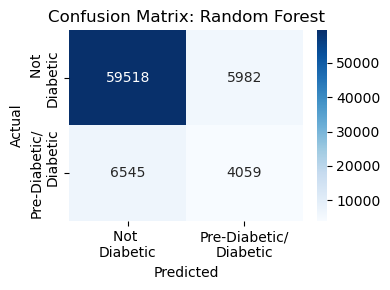

In [101]:
print("Confusion Matrix: Random Forest")
rfcm = confusion_matrix(y_test, y_pred)
plt.figure(figsize = (4,3))
sns.heatmap(rfcm, 
            annot=True, 
            fmt='d', 
            cmap='Blues', 
            xticklabels=['Not \nDiabetic', 'Pre-Diabetic/\nDiabetic'], 
            yticklabels=['Not \nDiabetic', 'Pre-Diabetic/\nDiabetic'])
plt.title("Confusion Matrix: Random Forest")
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

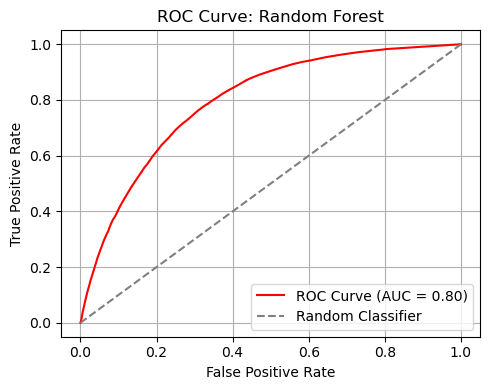

In [102]:
fpr, tpr, _ = roc_curve(y_test, y_prob) #three arrays: fpr, tpr, thresholds
roc_auc = auc(fpr, tpr)

plt.figure(figsize = (5,4))
plt.plot(fpr, tpr, label=f"ROC Curve (AUC = {roc_auc:.2f})", color="red")
plt.plot([0, 1], 
         [0, 1], 
         linestyle='--', 
         color="gray", 
         label = 'Random Classifier')  # Random guess line
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.grid(True)
plt.title("ROC Curve: Random Forest")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

In [103]:
roc_auc = roc_auc_score(y_test, y_prob)
print(f"ROC-AUC Score: {roc_auc:.4f}")

ROC-AUC Score: 0.7955


In [104]:
importance = pd.Series(rfModel.feature_importances_, index = feature_names).sort_values(key = abs, ascending = False)
# print(importance.head(50))

In [105]:
rf_grid = RandomForestClassifier()

In [106]:
param_grid = {'n_estimators': [50, 100, 200, 300],
             'max_depth': [3, 5, 7],
             'max_features': ['auto', 'sqrt'],
             'min_samples_leaf': [1, 2, 4]}

In [107]:
gs = GridSearchCV(rf_grid,  
                  param_grid, cv =5, 
                  scoring = 'f1', 
                  verbose = 0) # does not show the parameters exhausted
grid_result = gs.fit(X_train_smote, y_train_smote)

C:\Users\cathy\miniconda3\envs\catenv\Lib\site-packages\sklearn\model_selection\_validation.py:516: FitFailedWarning: 
180 fits failed out of a total of 360.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
180 fits failed with the following error:
Traceback (most recent call last):
  File "C:\Users\cathy\miniconda3\envs\catenv\Lib\site-packages\sklearn\model_selection\_validation.py", line 859, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
    ~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\cathy\miniconda3\envs\catenv\Lib\site-packages\sklearn\base.py", line 1358, in wrapper
    estimator._validate_params()
    ~~~~~~~~~~~~~~~~~~~~~~~~~~^^
  File "C:\Users\cathy\miniconda3\envs\catenv\Lib\site-packag

In [110]:
print(f"Best parameter:{grid_result.best_params_}")

Best parameter:{'max_depth': 7, 'max_features': 'sqrt', 'min_samples_leaf': 4, 'n_estimators': 50}


In [111]:
print(f"Best score CV is {grid_result.best_score_}")

Best score CV is 0.7913583035074965


In [112]:
rf_best = grid_result.best_estimator_
y_pred = rf_best.predict(X_test)
y_prob = rf_best.predict_proba(X_test)[:,1]

In [113]:
# Metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1 Score: {f1:.4f}")

Accuracy: 0.7460
Precision: 0.3140
Recall: 0.6946
F1 Score: 0.4325


In [114]:
print(classification_report(y_test, y_pred, digits=4))

              precision    recall  f1-score   support

       False     0.9385    0.7544    0.8364     65500
        True     0.3140    0.6946    0.4325     10604

    accuracy                         0.7460     76104
   macro avg     0.6263    0.7245    0.6345     76104
weighted avg     0.8515    0.7460    0.7801     76104



Confusion Matrix: 


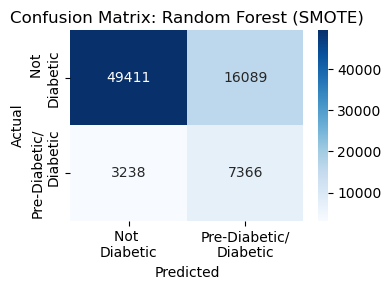

In [115]:
print("Confusion Matrix: ")
rf_best_cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize = (4,3))
sns.heatmap(rf_best_cm, 
            annot=True, 
            fmt='d', 
            cmap='Blues', 
            xticklabels=['Not \nDiabetic', 'Pre-Diabetic/\nDiabetic'], 
            yticklabels=['Not \nDiabetic', 'Pre-Diabetic/\nDiabetic'])
plt.title("Confusion Matrix: Random Forest (SMOTE)")
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

In [116]:
roc_auc = roc_auc_score(y_test, y_prob)
print(f"ROC-AUC Score: {roc_auc:.4f}")

ROC-AUC Score: 0.8072


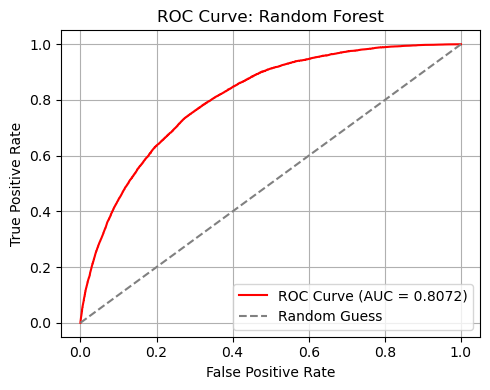

In [117]:
fpr, tpr, _ = roc_curve(y_test, y_prob) #three arrays: fpr, tpr, thresholds
roc_auc = auc(fpr, tpr)

plt.figure(figsize = (5,4))
plt.plot(fpr, tpr, label=f"ROC Curve (AUC = {roc_auc:.4f})", color="red")
plt.plot([0, 1], [0, 1], linestyle='--', color="gray", label = 'Random Guess')  # Random guess line
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.grid(True)
plt.title("ROC Curve: Random Forest")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

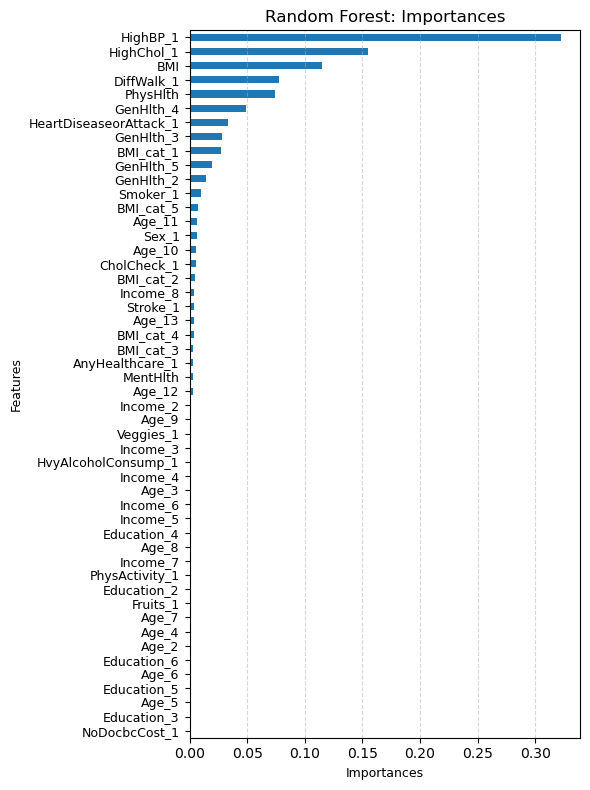

In [118]:
importances = pd.Series(rf_best.feature_importances_, 
                        index = X_train.columns)
plt.figure(figsize=(6, 8))
importances.sort_values(ascending= False).plot.barh()
plt.gca().invert_yaxis()
plt.grid(axis="x", 
         linestyle="--", 
         alpha=0.5)
plt.title('Random Forest: Importances')
plt.xlabel('Importances', 
           fontsize = 9)
plt.ylabel('Features', 
           fontsize = 9)
plt.yticks(fontsize = 9)
plt.tight_layout()
plt.show()

In [119]:
# importances

In [120]:
featXImportance_df = pd.DataFrame({'feature': X_train.columns,
                                   'importance': importances}).sort_values(by='importance', ascending=False)


cutoff = .01
rf_select = featXImportance_df[featXImportance_df['importance'] >= cutoff]
rf_select

,feature,importance
HighBP_1,HighBP_1,0.322660
HighChol_1,HighChol_1,0.154712
BMI,BMI,0.114801
DiffWalk_1,DiffWalk_1,0.077818
PhysHlth,PhysHlth,0.074587
GenHlth_4,GenHlth_4,0.048623
HeartDiseaseorAttack_1,HeartDiseaseorAttack_1,0.033361
GenHlth_3,GenHlth_3,0.028013
BMI_cat_1,BMI_cat_1,0.026936
GenHlth_5,GenHlth_5,0.019091


In [122]:
# sorted(rf_select.importance.index)

['BMI',
 'BMI_cat_1',
 'DiffWalk_1',
 'GenHlth_2',
 'GenHlth_3',
 'GenHlth_4',
 'GenHlth_5',
 'HeartDiseaseorAttack_1',
 'HighBP_1',
 'HighChol_1',
 'PhysHlth']

In [123]:
rf_deselect = featXImportance_df[featXImportance_df['importance'] < cutoff]
# sorted(rf_deselect.importance.index)

<Figure size 600x800 with 0 Axes>

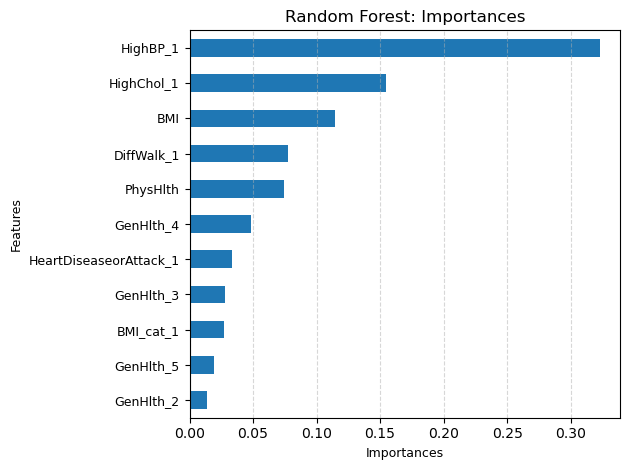

In [124]:
cutoff = .01
plt.figure(figsize=(6, 8))
rf_select = featXImportance_df[featXImportance_df['importance'] >= cutoff]
rf_select.plot.barh(legend = False)
plt.gca().invert_yaxis()
plt.grid(axis="x", 
         linestyle="--", 
         alpha=0.5)
plt.title('Random Forest: Importances')
plt.xlabel('Importances', 
           fontsize = 9)
plt.ylabel('Features', 
           fontsize = 9)
plt.yticks(fontsize = 9)
plt.tight_layout()
plt.show()


In [147]:
sample_weights = compute_sample_weight(class_weight = 'balanced', y = y_train)

In [148]:
XGBmodel = xgb.XGBClassifier(n_estimators = 100, # Number of trees
                             max_depth = 4, # Tree depth
                             learning_rate = 0.1, # Step size shrinkage
                             subsample = 0.8, # Row sampling
                             colsample_bytree = 0.8, # Feature sampling
                             random_state = 0,
                             use_label_encoder = False,
                             eval_metric='logloss') # Avoids warning for default metric

In [149]:
XGBmodel.fit(X_train, y_train, sample_weight=sample_weights)

C:\Users\cathy\miniconda3\envs\catenv\Lib\site-packages\xgboost\training.py:199: UserWarning: [05:24:56] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.8
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,'logloss'


In [150]:
y_pred = XGBmodel.predict(X_test)
y_prob = XGBmodel.predict_proba(X_test)[:, 1] #positive

In [151]:
# Metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1 Score: {f1:.4f}")


Accuracy: 0.7275
Precision: 0.3094
Recall: 0.7760
F1 Score: 0.4424


In [152]:
print(classification_report(y_test, y_pred, digits=4))

              precision    recall  f1-score   support

       False     0.9520    0.7196    0.8197     65500
        True     0.3094    0.7760    0.4424     10604

    accuracy                         0.7275     76104
   macro avg     0.6307    0.7478    0.6311     76104
weighted avg     0.8625    0.7275    0.7671     76104



Confusion Matrix:


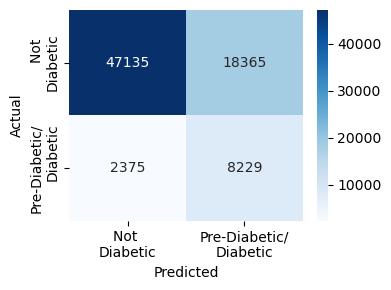

In [153]:
print("Confusion Matrix:")
XGBcm = confusion_matrix(y_test, y_pred)
plt.figure(figsize = (4,3))
sns.heatmap(XGBcm, annot=True, fmt='d', cmap='Blues', xticklabels=['Not \nDiabetic', 'Pre-Diabetic/\nDiabetic'], yticklabels=['Not \nDiabetic', 'Pre-Diabetic/\nDiabetic'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

In [154]:
roc_auc = roc_auc_score(y_test, y_prob)
print(f"ROC-AUC Score: {roc_auc:.4f}")

ROC-AUC Score: 0.8272


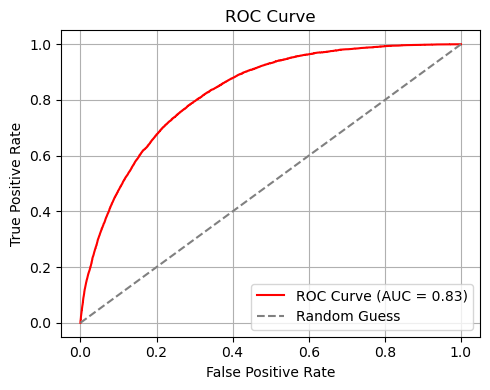

In [155]:
fpr, tpr, _ = roc_curve(y_test, y_prob) #three arrays: fpr, tpr, thresholds
roc_auc = auc(fpr, tpr)

plt.figure(figsize = (5,4))
plt.plot(fpr, tpr, label=f"ROC Curve (AUC = {roc_auc:.2f})", color="red")
plt.plot([0, 1], [0, 1], linestyle='--', color="gray", label = 'Random Guess')  # Random guess line
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.grid(True)
plt.title("ROC Curve")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

In [156]:
importance = pd.Series(XGBmodel.feature_importances_, index = feature_names).sort_values(ascending = False)
print(importance.head(30))

HighBP_1                  0.365168
HighChol_1                0.060792
DiffWalk_1                0.053551
GenHlth_3                 0.047325
GenHlth_4                 0.042309
BMI_cat_1                 0.040803
GenHlth_2                 0.037669
HeartDiseaseorAttack_1    0.028918
Income_8                  0.024355
BMI                       0.024308
GenHlth_5                 0.022349
Age_2                     0.018029
Age_11                    0.017465
Age_3                     0.016884
BMI_cat_2                 0.015377
Age_12                    0.015371
CholCheck_1               0.014613
Age_4                     0.014350
Age_10                    0.013929
Age_5                     0.013534
HvyAlcoholConsump_1       0.013448
Age_6                     0.010134
Age_13                    0.009375
Sex_1                     0.006914
Age_9                     0.006183
Education_6               0.005539
PhysHlth                  0.005368
BMI_cat_5                 0.005174
Stroke_1            

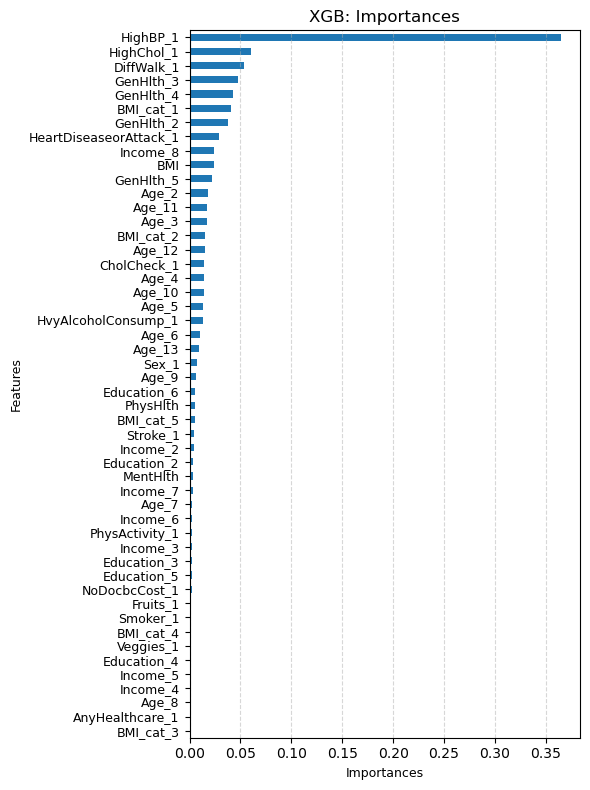

In [157]:
importances = pd.Series(XGBmodel.feature_importances_, 
                        index = X_train.columns)
plt.figure(figsize=(6, 8))
importances.sort_values(ascending= False).plot.barh() #gain
plt.gca().invert_yaxis()
plt.grid(axis="x", 
         linestyle="--", 
         alpha=0.5)
plt.title('XGB: Importances')
plt.xlabel('Importances',
           fontsize = 9)
plt.ylabel('Features', 
           fontsize = 9)
plt.yticks(fontsize = 9)
plt.tight_layout()
plt.show()

In [158]:
featXImportance_df = pd.DataFrame({'feature': X_train.columns,
                                   'importance': importances}).sort_values(by='importance', ascending=False)

cutoff = .01
xgb_select = featXImportance_df[featXImportance_df['importance'] >= cutoff]
xgb_select

,feature,importance
HighBP_1,HighBP_1,0.365168
HighChol_1,HighChol_1,0.060792
DiffWalk_1,DiffWalk_1,0.053551
GenHlth_3,GenHlth_3,0.047325
GenHlth_4,GenHlth_4,0.042309
BMI_cat_1,BMI_cat_1,0.040803
GenHlth_2,GenHlth_2,0.037669
HeartDiseaseorAttack_1,HeartDiseaseorAttack_1,0.028918
Income_8,Income_8,0.024355
BMI,BMI,0.024308


In [159]:
sorted(xgb_select.importance.index)

['Age_10',
 'Age_11',
 'Age_12',
 'Age_2',
 'Age_3',
 'Age_4',
 'Age_5',
 'Age_6',
 'BMI',
 'BMI_cat_1',
 'BMI_cat_2',
 'CholCheck_1',
 'DiffWalk_1',
 'GenHlth_2',
 'GenHlth_3',
 'GenHlth_4',
 'GenHlth_5',
 'HeartDiseaseorAttack_1',
 'HighBP_1',
 'HighChol_1',
 'HvyAlcoholConsump_1',
 'Income_8']

In [160]:
xgb_deselect = featXImportance_df[featXImportance_df['importance'] < cutoff]
sorted(xgb_deselect.index)

['Age_13',
 'Age_7',
 'Age_8',
 'Age_9',
 'AnyHealthcare_1',
 'BMI_cat_3',
 'BMI_cat_4',
 'BMI_cat_5',
 'Education_2',
 'Education_3',
 'Education_4',
 'Education_5',
 'Education_6',
 'Fruits_1',
 'Income_2',
 'Income_3',
 'Income_4',
 'Income_5',
 'Income_6',
 'Income_7',
 'MentHlth',
 'NoDocbcCost_1',
 'PhysActivity_1',
 'PhysHlth',
 'Sex_1',
 'Smoker_1',
 'Stroke_1',
 'Veggies_1']

In [161]:
XGBmodel = xgb.XGBClassifier(n_estimators = 100, # Number of trees
                             max_depth = 4, # Tree depth
                             learning_rate = 0.1, # Step size shrinkage
                             subsample = 0.8, # Row sampling
                             colsample_bytree = 0.8, # Feature sampling
                             random_state = 0,
                             use_label_encoder = False,
                             eval_metric="logloss") # Avoids warning for default metric

In [162]:
XGBmodel.fit(X_train[xgb_select.index], y_train, sample_weight= sample_weights)


C:\Users\cathy\miniconda3\envs\catenv\Lib\site-packages\xgboost\training.py:199: UserWarning: [05:24:59] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.8
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,'logloss'


In [163]:
y_pred = XGBmodel.predict(X_test[xgb_select.index])
y_prob = XGBmodel.predict_proba(X_test[xgb_select.index])[:, 1] #positive

In [164]:
# Metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1 Score: {f1:.4f}")


Accuracy: 0.7206
Precision: 0.3037
Recall: 0.7775
F1 Score: 0.4368


In [165]:
print(classification_report(y_test, y_pred, digits=4))

              precision    recall  f1-score   support

       False     0.9518    0.7114    0.8142     65500
        True     0.3037    0.7775    0.4368     10604

    accuracy                         0.7206     76104
   macro avg     0.6278    0.7445    0.6255     76104
weighted avg     0.8615    0.7206    0.7617     76104



Confusion Matrix:


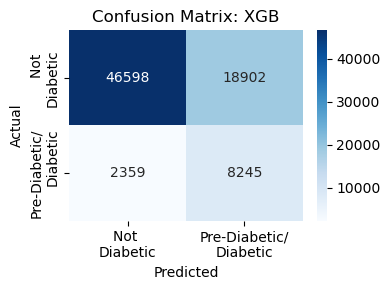

In [166]:
print("Confusion Matrix:")
XGBcm = confusion_matrix(y_test, y_pred)
plt.figure(figsize = (4,3))
sns.heatmap(XGBcm, 
            annot=True, 
            fmt='d', 
            cmap='Blues', 
            xticklabels=['Not \nDiabetic', 'Pre-Diabetic/\nDiabetic'], 
            yticklabels=['Not \nDiabetic', 'Pre-Diabetic/\nDiabetic'])
plt.title("Confusion Matrix: XGB")
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

In [167]:
roc_auc = roc_auc_score(y_test, y_prob)
print(f"ROC-AUC Score: {roc_auc:.4f}")

ROC-AUC Score: 0.8239


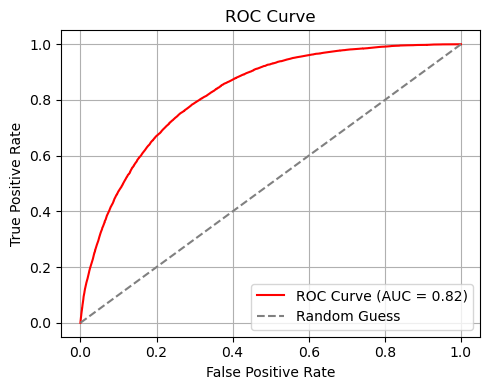

In [168]:
fpr, tpr, _ = roc_curve(y_test, y_prob) #three arrays: fpr, tpr, thresholds
roc_auc = auc(fpr, tpr)

plt.figure(figsize = (5,4))
plt.plot(fpr, tpr, label=f"ROC Curve (AUC = {roc_auc:.2f})", color="red")
plt.plot([0, 1], [0, 1], linestyle='--', color="gray", label = 'Random Guess')  # Random guess line
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.grid(True)
plt.title("ROC Curve")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

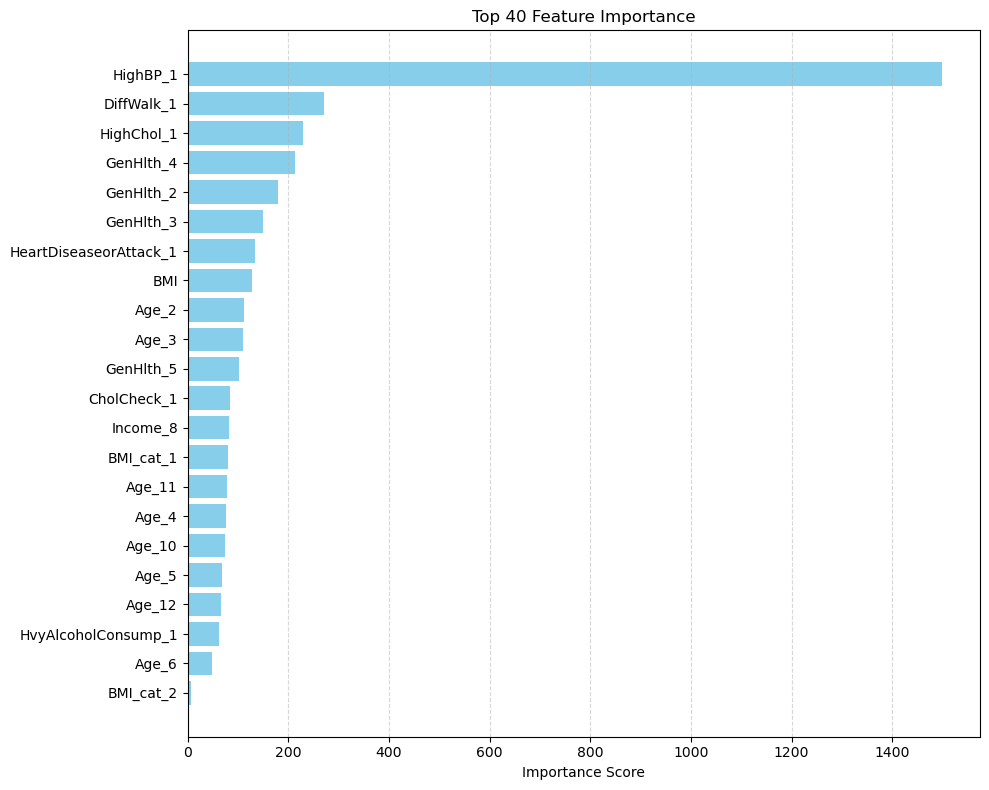

In [169]:
importance = XGBmodel.get_booster().get_score(importance_type='gain')

importance_df = pd.DataFrame({'Feature': list(importance.keys()),
                              'Importance': list(importance.values())}).sort_values(by='Importance', ascending=False)

top_n = 40
plt.figure(figsize=(10, 8))
plt.barh(
    importance_df['Feature'].head(top_n)[::-1],
    importance_df['Importance'].head(top_n)[::-1],
    color='skyblue'
)
plt.grid(axis="x", 
         linestyle="--", 
         alpha=0.5)
plt.xlabel('Importance Score')
plt.title(f'Top {top_n} Feature Importance')
plt.tight_layout()

In [170]:
X_train[xgb_select.index].columns

Index(['HighBP_1', 'HighChol_1', 'DiffWalk_1', 'GenHlth_3', 'GenHlth_4',
       'BMI_cat_1', 'GenHlth_2', 'HeartDiseaseorAttack_1', 'Income_8', 'BMI',
       'GenHlth_5', 'Age_2', 'Age_11', 'Age_3', 'BMI_cat_2', 'Age_12',
       'CholCheck_1', 'Age_4', 'Age_10', 'Age_5', 'HvyAlcoholConsump_1',
       'Age_6'],
      dtype='object')

### XGB CHECK

In [125]:
scale_pos_weight = len(y_train[y_train == 0]) / len(y_train[y_train == 1])

XGBmodel = xgb.XGBClassifier(n_estimators = 100, # Number of trees
                             max_depth = 4, # Tree depth
                             learning_rate = 0.1, # Step size shrinkage
                             subsample = 0.8, # Row sampling
                             colsample_bytree = 0.8, # Feature sampling
                             objective='binary:logistic',
                             scale_pos_weight = scale_pos_weight,
                             random_state = 0,
                             use_label_encoder = False,
                             eval_metric=['logloss', 'auc'])

In [126]:
XGBmodel.fit(X_train, y_train)

C:\Users\cathy\miniconda3\envs\catenv\Lib\site-packages\xgboost\training.py:199: UserWarning: [03:15:23] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.8
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,"['logloss', 'auc']"


In [127]:
y_pred = XGBmodel.predict(X_test)
y_prob = XGBmodel.predict_proba(X_test)[:, 1] #positive

In [128]:
# Metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1 Score: {f1:.4f}")


Accuracy: 0.7270
Precision: 0.3090
Recall: 0.7759
F1 Score: 0.4420


In [129]:
print(classification_report(y_test, y_pred, digits=4))

              precision    recall  f1-score   support

       False     0.9520    0.7191    0.8193     65500
        True     0.3090    0.7759    0.4420     10604

    accuracy                         0.7270     76104
   macro avg     0.6305    0.7475    0.6306     76104
weighted avg     0.8624    0.7270    0.7667     76104



Confusion Matrix:


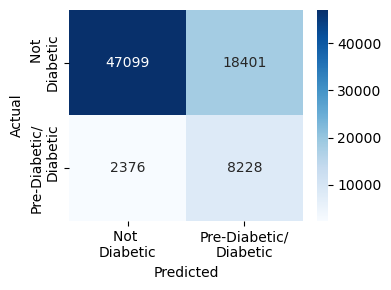

In [130]:
print("Confusion Matrix:")
XGBcm = confusion_matrix(y_test, y_pred)
plt.figure(figsize = (4,3))
sns.heatmap(XGBcm, annot=True, fmt='d', cmap='Blues', xticklabels=['Not \nDiabetic', 'Pre-Diabetic/\nDiabetic'], yticklabels=['Not \nDiabetic', 'Pre-Diabetic/\nDiabetic'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

In [131]:
roc_auc = roc_auc_score(y_test, y_prob)
print(f"ROC-AUC Score: {roc_auc:.4f}")

ROC-AUC Score: 0.8273


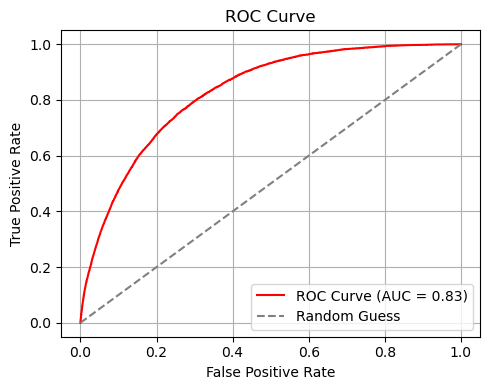

In [132]:
fpr, tpr, _ = roc_curve(y_test, y_prob) #three arrays: fpr, tpr, thresholds
roc_auc = auc(fpr, tpr)

plt.figure(figsize = (5,4))
plt.plot(fpr, tpr, label=f"ROC Curve (AUC = {roc_auc:.2f})", color="red")
plt.plot([0, 1], [0, 1], linestyle='--', color="gray", label = 'Random Guess')  # Random guess line
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.grid(True)
plt.title("ROC Curve")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

In [133]:
importance = pd.Series(XGBmodel.feature_importances_, index = feature_names).sort_values(ascending = False)
print(importance.head(30))

feature: HighBP_1                  0.312594
feature: HighChol_1                0.068931
feature: DiffWalk_1                0.057397
feature: GenHlth_4                 0.050360
feature: GenHlth_3                 0.047767
feature: GenHlth_2                 0.045994
feature: BMI_cat_1                 0.039448
feature: HeartDiseaseorAttack_1    0.028539
feature: Income_8                  0.028107
feature: BMI                       0.027256
feature: GenHlth_5                 0.024791
feature: Age_3                     0.018941
feature: Age_2                     0.017831
feature: Age_12                    0.017782
feature: Age_11                    0.017385
feature: BMI_cat_2                 0.016250
feature: CholCheck_1               0.015921
feature: Age_4                     0.014450
feature: Age_10                    0.013792
feature: Age_5                     0.013362
feature: HvyAlcoholConsump_1       0.013130
feature: Age_6                     0.011696
feature: Age_13                 

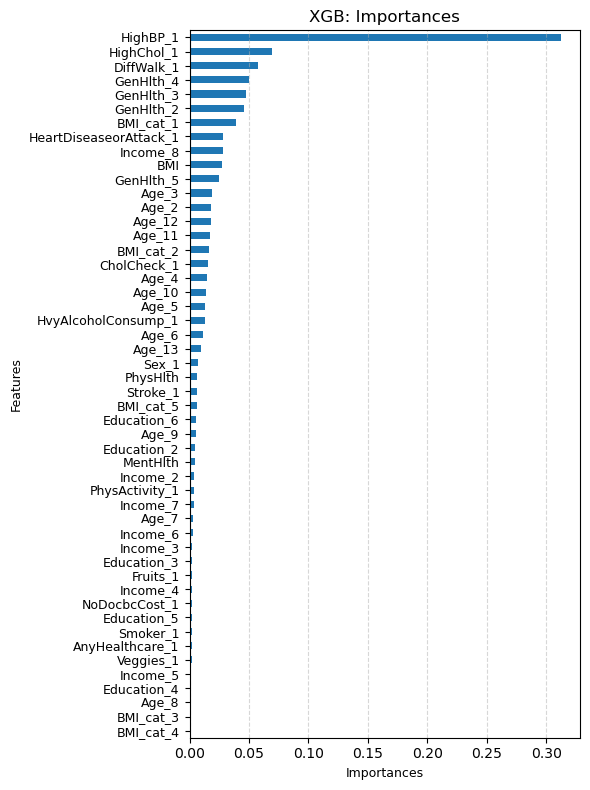

In [134]:
importances = pd.Series(XGBmodel.feature_importances_, 
                        index = X_train.columns)
plt.figure(figsize=(6, 8))
importances.sort_values(ascending= False).plot.barh() #gain
plt.gca().invert_yaxis()
plt.grid(axis="x", 
         linestyle="--", 
         alpha=0.5)
plt.title('XGB: Importances')
plt.xlabel('Importances',
           fontsize = 9)
plt.ylabel('Features', 
           fontsize = 9)
plt.yticks(fontsize = 9)
plt.tight_layout()
plt.show()

In [135]:
featXImportance_df = pd.DataFrame({'feature': X_train.columns,
                                   'importance': importances}).sort_values(by='importance', ascending=False)

cutoff = .01
xgb_select = featXImportance_df[featXImportance_df['importance'] >= cutoff]
xgb_select

,feature,importance
HighBP_1,HighBP_1,0.312594
HighChol_1,HighChol_1,0.068931
DiffWalk_1,DiffWalk_1,0.057397
GenHlth_4,GenHlth_4,0.050360
GenHlth_3,GenHlth_3,0.047767
GenHlth_2,GenHlth_2,0.045994
BMI_cat_1,BMI_cat_1,0.039448
HeartDiseaseorAttack_1,HeartDiseaseorAttack_1,0.028539
Income_8,Income_8,0.028107
BMI,BMI,0.027256


In [182]:
# sorted(xgb_select.importance.index)

['Age_10',
 'Age_11',
 'Age_12',
 'Age_2',
 'Age_3',
 'Age_4',
 'Age_5',
 'Age_6',
 'BMI',
 'BMI_cat_1',
 'BMI_cat_2',
 'CholCheck_1',
 'DiffWalk_1',
 'GenHlth_2',
 'GenHlth_3',
 'GenHlth_4',
 'GenHlth_5',
 'HeartDiseaseorAttack_1',
 'HighBP_1',
 'HighChol_1',
 'HvyAlcoholConsump_1',
 'Income_8']

In [145]:
xgb_deselect = featXImportance_df[featXImportance_df['importance'] < cutoff]
# sorted(xgb_deselect.index)

In [146]:
XGBmodel = xgb.XGBClassifier(n_estimators = 100, # Number of trees
                             max_depth = 4, # Tree depth
                             learning_rate = 0.1, # Step size shrinkage
                             subsample = 0.8, # Row sampling
                             colsample_bytree = 0.8, # Feature sampling
                             objective='binary:logistic',
                             scale_pos_weight=scale_pos_weight,
                             random_state = 0,
                             use_label_encoder = False,
                             eval_metric=['logloss', 'auc'])

In [147]:
XGBmodel.fit(X_train[xgb_select.index], y_train)


C:\Users\cathy\miniconda3\envs\catenv\Lib\site-packages\xgboost\training.py:199: UserWarning: [03:20:33] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.8
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,"['logloss', 'auc']"


In [148]:
y_pred = XGBmodel.predict(X_test[xgb_select.index])
y_prob = XGBmodel.predict_proba(X_test[xgb_select.index])[:, 1] #positive

In [149]:
# Metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1 Score: {f1:.4f}")


Accuracy: 0.7194
Precision: 0.3029
Recall: 0.7790
F1 Score: 0.4362


In [150]:
print(classification_report(y_test, y_pred, digits=4))

              precision    recall  f1-score   support

       False     0.9520    0.7097    0.8132     65500
        True     0.3029    0.7790    0.4362     10604

    accuracy                         0.7194     76104
   macro avg     0.6274    0.7444    0.6247     76104
weighted avg     0.8616    0.7194    0.7607     76104



Confusion Matrix:


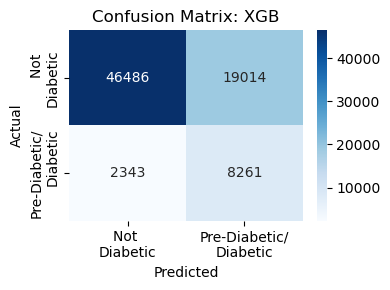

In [151]:
print("Confusion Matrix:")
XGBcm = confusion_matrix(y_test, y_pred)
plt.figure(figsize = (4,3))
sns.heatmap(XGBcm, 
            annot=True, 
            fmt='d', 
            cmap='Blues', 
            xticklabels=['Not \nDiabetic', 'Pre-Diabetic/\nDiabetic'], 
            yticklabels=['Not \nDiabetic', 'Pre-Diabetic/\nDiabetic'])
plt.title("Confusion Matrix: XGB")
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

In [152]:
roc_auc = roc_auc_score(y_test, y_prob)
print(f"ROC-AUC Score: {roc_auc:.4f}")

ROC-AUC Score: 0.8238


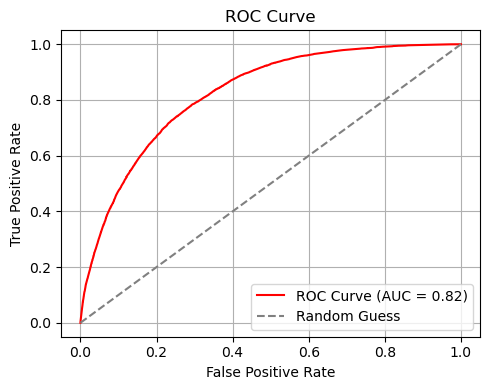

In [153]:
fpr, tpr, _ = roc_curve(y_test, y_prob) #three arrays: fpr, tpr, thresholds
roc_auc = auc(fpr, tpr)

plt.figure(figsize = (5,4))
plt.plot(fpr, tpr, label=f"ROC Curve (AUC = {roc_auc:.2f})", color="red")
plt.plot([0, 1], [0, 1], linestyle='--', color="gray", label = 'Random Guess')  # Random guess line
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.grid(True)
plt.title("ROC Curve")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

### KNN

In [52]:
knnModel = KNeighborsClassifier(n_neighbors=5)

In [53]:
knnModel.fit(X_train, y_train)

,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [54]:
y_pred = knnModel.predict(X_test)
y_prob = knnModel.predict_proba(X_test)[:,1]


In [55]:
# Metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"Accuracy: {accuracy:.2f}")
print(f"Precision: {precision:.2f}")
print(f"Recall: {recall:.2f}")
print(f"F1 Score: {f1:.2f}")


Accuracy: 0.85
Precision: 0.42
Recall: 0.21
F1 Score: 0.28


In [56]:
print(classification_report(y_test, y_pred, digits=4))

              precision    recall  f1-score   support

       False     0.8816    0.9536    0.9162     65500
        True     0.4220    0.2092    0.2797     10604

    accuracy                         0.8499     76104
   macro avg     0.6518    0.5814    0.5980     76104
weighted avg     0.8176    0.8499    0.8275     76104



Confusion Matrix:


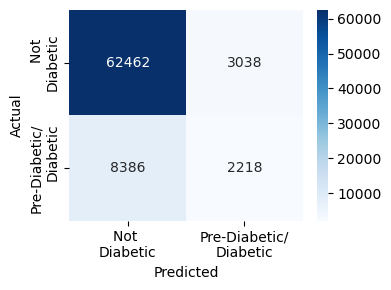

In [198]:
print("Confusion Matrix:")
KNNcm = confusion_matrix(y_test, y_pred)
plt.figure(figsize = (4,3))
sns.heatmap(KNNcm, 
            annot = True, 
            fmt = 'd', 
            cmap='Blues', 
            xticklabels=['Not \nDiabetic', 'Pre-Diabetic/\nDiabetic'], 
            yticklabels=['Not \nDiabetic', 'Pre-Diabetic/\nDiabetic'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

In [199]:
roc_auc = roc_auc_score(y_test, y_prob)
print(f"ROC-AUC Score: {roc_auc:.4f}")

ROC-AUC Score: 0.7157


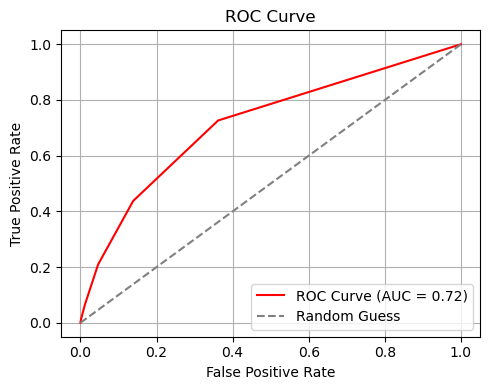

In [200]:
fpr, tpr, _ = roc_curve(y_test, y_prob) #three arrays: fpr, tpr, thresholds
roc_auc = auc(fpr, tpr)

plt.figure(figsize = (5,4))
plt.plot(fpr, tpr, label=f"ROC Curve (AUC = {roc_auc:.2f})", color="red")
plt.plot([0, 1], [0, 1], linestyle='--', color="gray", label = 'Random Guess')  # Random guess line
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.grid(True)
plt.title("ROC Curve")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

In [201]:
knnModel.fit(X_train_smote, y_train_smote)

,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [202]:
y_pred = knnModel.predict(X_test)
y_prob = knnModel.predict_proba(X_test)[:,1]

In [203]:
# Metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"Accuracy: {accuracy:.2f}")
print(f"Precision: {precision:.2f}")
print(f"Recall: {recall:.2f}")
print(f"F1 Score: {f1:.2f}")


Accuracy: 0.77
Precision: 0.30
Recall: 0.50
F1 Score: 0.38


In [204]:
print(classification_report(y_test, y_pred, digits=4))

              precision    recall  f1-score   support

       False     0.9100    0.8135    0.8591     65500
        True     0.3040    0.5031    0.3790     10604

    accuracy                         0.7703     76104
   macro avg     0.6070    0.6583    0.6190     76104
weighted avg     0.8256    0.7703    0.7922     76104



Confusion Matrix:


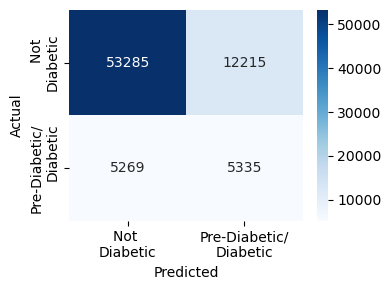

In [205]:
print("Confusion Matrix:")
KNNcm = confusion_matrix(y_test, y_pred)
plt.figure(figsize = (4,3))
sns.heatmap(KNNcm, 
            annot = True, 
            fmt = 'd', 
            cmap='Blues', 
            xticklabels=['Not \nDiabetic', 'Pre-Diabetic/\nDiabetic'], 
            yticklabels=['Not \nDiabetic', 'Pre-Diabetic/\nDiabetic'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

In [206]:
roc_auc = roc_auc_score(y_test, y_prob)
print(f"ROC-AUC Score: {roc_auc:.4f}")

ROC-AUC Score: 0.7255


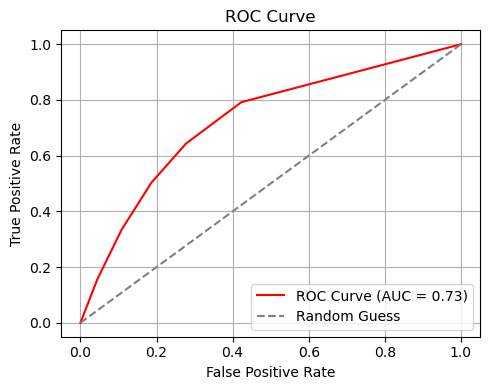

In [207]:
fpr, tpr, _ = roc_curve(y_test, y_prob) #three arrays: fpr, tpr, thresholds
roc_auc = auc(fpr, tpr)

plt.figure(figsize = (5,4))
plt.plot(fpr, tpr, label=f"ROC Curve (AUC = {roc_auc:.2f})", color="red")
plt.plot([0, 1], [0, 1], linestyle='--', color="gray", label = 'Random Guess')  # Random guess line
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.grid(True)
plt.title("ROC Curve")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

In [208]:
param_grid = {'n_neighbors': [3, 5],
              'weights': ['distance'],
              'metric': ['euclidean']}

In [209]:
gs = GridSearchCV(knnModel, 
                  param_grid, 
                  cv = 3, 
                  scoring = 'f1', 
                  n_jobs = -1)
gs_result = gs.fit(X_train_smote, y_train_smote)

In [210]:
print("Best parameters:", gs_result.best_params_)
print("Best CV score:", gs_result.best_score_)

Best parameters: {'metric': 'euclidean', 'n_neighbors': 3, 'weights': 'distance'}
Best CV score: 0.893521558372167


In [211]:
knn_best = gs_result.best_estimator_
y_pred = knn_best.predict(X_test)
y_prob = knn_best.predict_proba(X_test)[:,1]

In [212]:
# Metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1 Score: {f1:.4f}")


Accuracy: 0.7829
Precision: 0.3050
Recall: 0.4365
F1 Score: 0.3591


In [213]:
print(classification_report(y_test, y_pred, digits=4))

              precision    recall  f1-score   support

       False     0.9019    0.8390    0.8693     65500
        True     0.3050    0.4365    0.3591     10604

    accuracy                         0.7829     76104
   macro avg     0.6035    0.6378    0.6142     76104
weighted avg     0.8188    0.7829    0.7982     76104



Confusion Matrix:


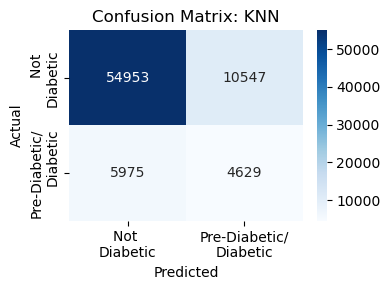

In [214]:
print("Confusion Matrix:")
KNNcm = confusion_matrix(y_test, y_pred)
plt.figure(figsize = (4,3))
sns.heatmap(KNNcm, 
            annot = True, 
            fmt = 'd', 
            cmap='Blues', 
            xticklabels=['Not \nDiabetic', 
                         'Pre-Diabetic/\nDiabetic'], 
            yticklabels=['Not \nDiabetic', 'Pre-Diabetic/\nDiabetic'])
plt.title("Confusion Matrix: KNN")
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

In [215]:
roc_auc = roc_auc_score(y_test, y_prob)
print(f"ROC-AUC Score: {roc_auc:.4f}")

ROC-AUC Score: 0.6943


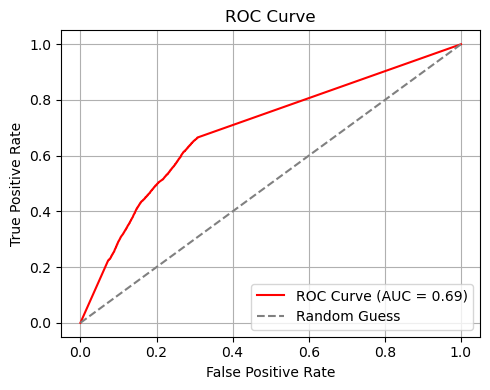

In [216]:
fpr, tpr, _ = roc_curve(y_test, y_prob) #three arrays: fpr, tpr, thresholds
roc_auc = auc(fpr, tpr)

plt.figure(figsize = (5,4))
plt.plot(fpr, tpr, label=f"ROC Curve (AUC = {roc_auc:.2f})", color="red")
plt.plot([0, 1], [0, 1], linestyle='--', color="gray", label = 'Random Guess')  # Random guess line
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.grid(True)
plt.title("ROC Curve")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

In [217]:
smote_sampling = SMOTE(random_state = 0)

In [218]:
X_train_smote, y_train_smote = smote_sampling.fit_resample(X_train, y_train)

In [222]:
svmModel = SVC(kernel = 'rbf', C = 1.0, probability=True, random_state = 0)

In [ ]:
svmModel.fit(X_train_smote, y_train_smote)

In [221]:
y_pred = svmModel.predict(X_test)
y_prob = svmModel.predict_proba(X_test)[:,1]

AttributeError: This 'SVC' has no attribute 'predict_proba'

In [ ]:
# Metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1 Score: {f1:.4f}")


In [ ]:
print(classification_report(y_test, y_pred, digits=4))

In [ ]:
print("Confusion Matrix:")
svn_cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize = (4,3))
sns.heatmap(svm_cm, 
            annot = True, 
            fmt = 'd', 
            cmap='Blues', 
            xticklabels=['No Disease', 'Disease'], 
            yticklabels=['No Disease', 'Disease'], 
            cbar=True)
plt.title("Confusion Matrix: KNN")
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

In [ ]:
roc_auc = roc_auc_score(y_test, y_prob)
print(f"ROC-AUC Score: {roc_auc:.4f}")

In [ ]:
fpr, tpr, _ = roc_curve(y_test, y_prob) #three arrays: fpr, tpr, thresholds
roc_auc = auc(fpr, tpr)

plt.figure(figsize = (5,4))
plt.plot(fpr, tpr, label=f"ROC Curve (AUC = {roc_auc:.2f})", color="red")
plt.plot([0, 1], [0, 1], linestyle='--', color="gray", label = 'Random Guess')  # Random guess line
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.grid(True)
plt.title("ROC Curve")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

In [ ]:
https://archive.ics.uci.edu/dataset/891/cdc+diabetes+health+indicators